#  Bài 20: Trực Quan hóa Dữ liệu Địa không gian

Trực quan hóa dữ liệu địa không gian là bước quan trọng giúp hiểu sâu và truyền đạt thông tin từ dữ liệu bản đồ, ảnh vệ tinh, và các lớp địa lý khác. Các thư viện Python như GeoPandas, Rasterio, Matplotlib, và Xarray cung cấp giải pháp mạnh mẽ để hiển thị, phân tích và so sánh dữ liệu vector, raster, chuỗi thời gian, cũng như kết hợp nhiều lớp dữ liệu trên cùng một biểu đồ.

## 20.1. Mục tiêu học tập

Sau khi hoàn thành bài học này, bạn sẽ có thể:
- Hiển thị dữ liệu vector (điểm, đường, đa giác) bằng GeoPandas và Matplotlib
- Hiển thị dữ liệu raster bằng Rasterio và Matplotlib
- Kết hợp vector và raster trên cùng một biểu đồ
- Tạo nhiều subplot để so sánh các lớp dữ liệu địa lý
- Trực quan hóa chuỗi thời gian raster với Xarray và Matplotlib

In [45]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## 20.2. Hiển thị dữ liệu vector
Phần này minh họa cách vẽ dữ liệu vector (điểm, đường, đa giác) bằng GeoPandas và Matplotlib. Dữ liệu vector được lấy từ trang web sau [link](https://geodata.ucdavis.edu/gadm)

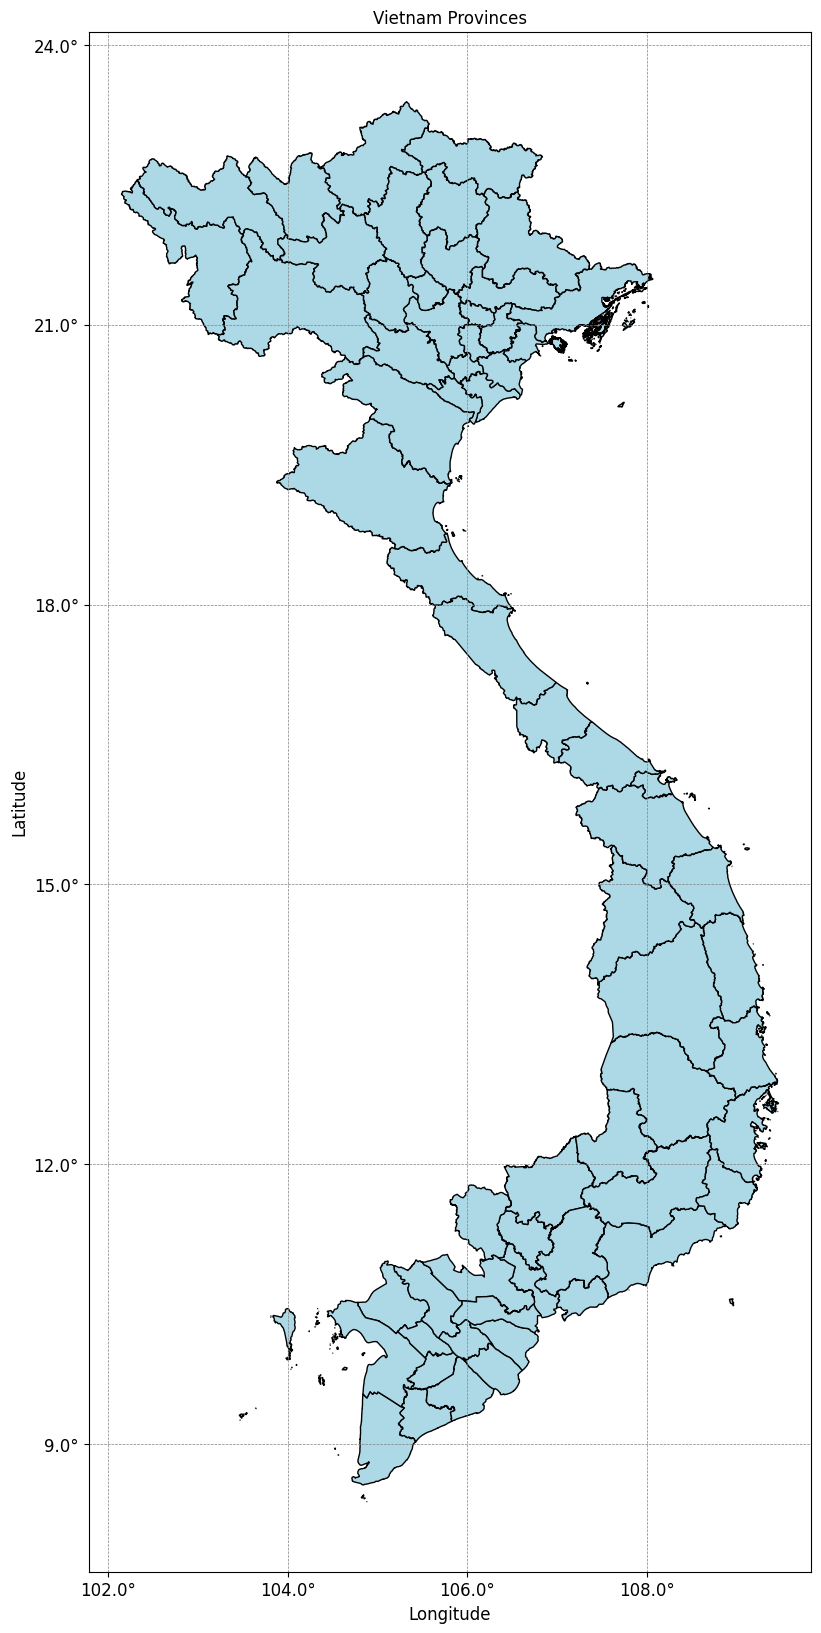

In [46]:
# Đọc dữ liệu vector từ URL và tạo bản đồ
vector_path = 'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_VNM_1.json'
gdf = gpd.read_file(vector_path)
# Tạo figure và axes
fig, ax = plt.subplots(figsize=(12, 20))
# Vẽ bản đồ với màu sắc và đường viền tùy chỉnh
gdf.plot(ax=ax, edgecolor='black', color='lightblue', legend=False)
# Thêm tiêu đề
ax.set_title('Vietnam Provinces')
# Tùy chỉnh trục và lưới
ax.grid(True, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Longitude', fontsize=12) # Thêm nhãn cho trục x
ax.set_ylabel('Latitude', fontsize=12) # Thêm nhãn cho trục y
# Thiết lập khoảng cách giữa các nhãn trục x và y
ax.xaxis.set_major_locator(ticker.MultipleLocator(2)) # Khoảng cách 2 độ giữa các nhãn trục x
ax.yaxis.set_major_locator(ticker.MultipleLocator(3)) # Khoảng cách 3 độ giữa các nhãn trục y
# format the x/y-axis to show longitude and latitude values with degree symbol
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.1f}°')) # Format trục x để hiển thị giá trị kinh độ với ký hiệu độ
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y:.1f}°')) # Format trục y để hiển thị giá trị vĩ độ với ký hiệu độ
ax.tick_params(axis='both', which='major', labelsize=12) # Tùy chỉnh kích thước chữ trục
plt.show()

## 20.3. Hiển thị dữ liệu raster
Phần này minh họa cách hiển thị dữ liệu raster bằng `Rioxarray` và `Matplotlib`.

In [ ]:
import rioxarray as rxr

In [48]:
# Đọc dữ liệu raster từ URL và hiển thị thông tin cơ bản
raw_url = "https://raw.githubusercontent.com/tuyenhavan/geospatial_course/main/data/raster/era5_temp_2020_2024_vietnam.tif"
temp = rxr.open_rasterio(f"/vsicurl/{raw_url}")
temp.attrs = {}

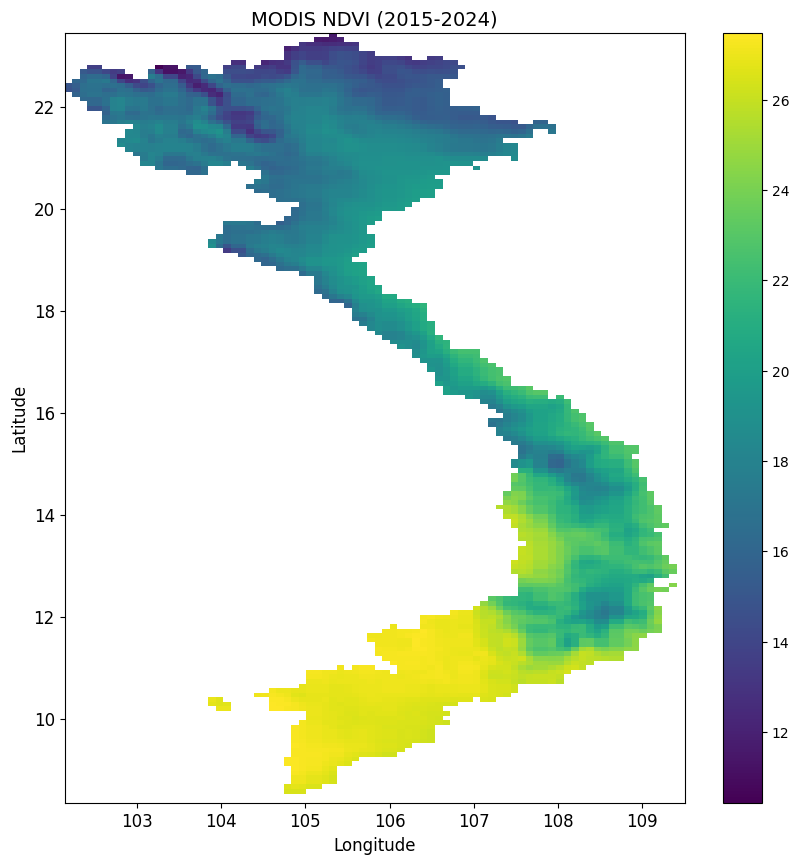

In [49]:
# Tạo figure và axes
fig, ax = plt.subplots(figsize=(10, 10))
# Hiển thị raster với colormap tùy chỉnh
first = temp[0]  # Chọn băng đầu tiên để hiển thị
first.plot(ax=ax, cmap='viridis')  # Sử dụng colormap 'viridis' để hiển thị raster
# Thêm tiêu đề và nhãn trục
ax.set_title('MODIS NDVI (2015-2024)', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12) # Thêm nhãn cho trục x
ax.set_ylabel('Latitude', fontsize=12) # Thêm nhãn cho trục y
ax.tick_params(axis='both', which='major', labelsize=12) # Tùy chỉnh kích thước chữ trục
plt.show()

## 20.4. Hiển thị đồng thời vector và raster trên cùng một biểu đồ
Phần này minh họa cách chồng dữ liệu vector lên raster để trực quan hóa kết hợp.

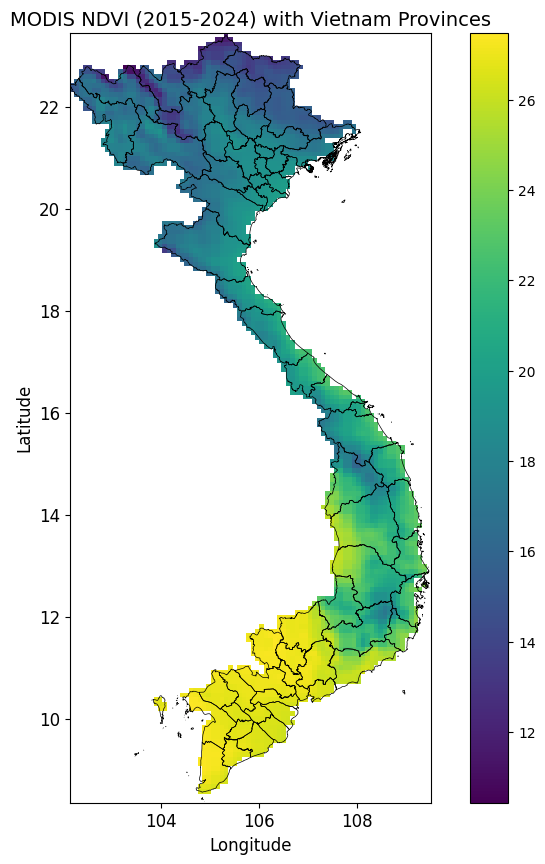

In [50]:
# Tạo figure và axes
fig, ax = plt.subplots(figsize=(10, 10))
# Hiển thị raster với colormap tùy chỉnh
first.plot(ax=ax, cmap='viridis')  # Sử dụng colormap 'viridis' để hiển thị raster
# Vẽ đường viền của các tỉnh lên trên raster
gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)
# Thêm tiêu đề và nhãn trục
ax.set_title('MODIS NDVI (2015-2024) with Vietnam Provinces', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12) # Thêm nhãn cho trục x
ax.set_ylabel('Latitude', fontsize=12) # Thêm nhãn cho trục y
ax.tick_params(axis='both', which='major', labelsize=12) # Tùy chỉnh kích thước chữ trục
plt.show()

## 20.5. Hiển thị nhiều subplot
Phần này minh họa cách tạo nhiều subplot để so sánh các lớp dữ liệu địa lý khác nhau.

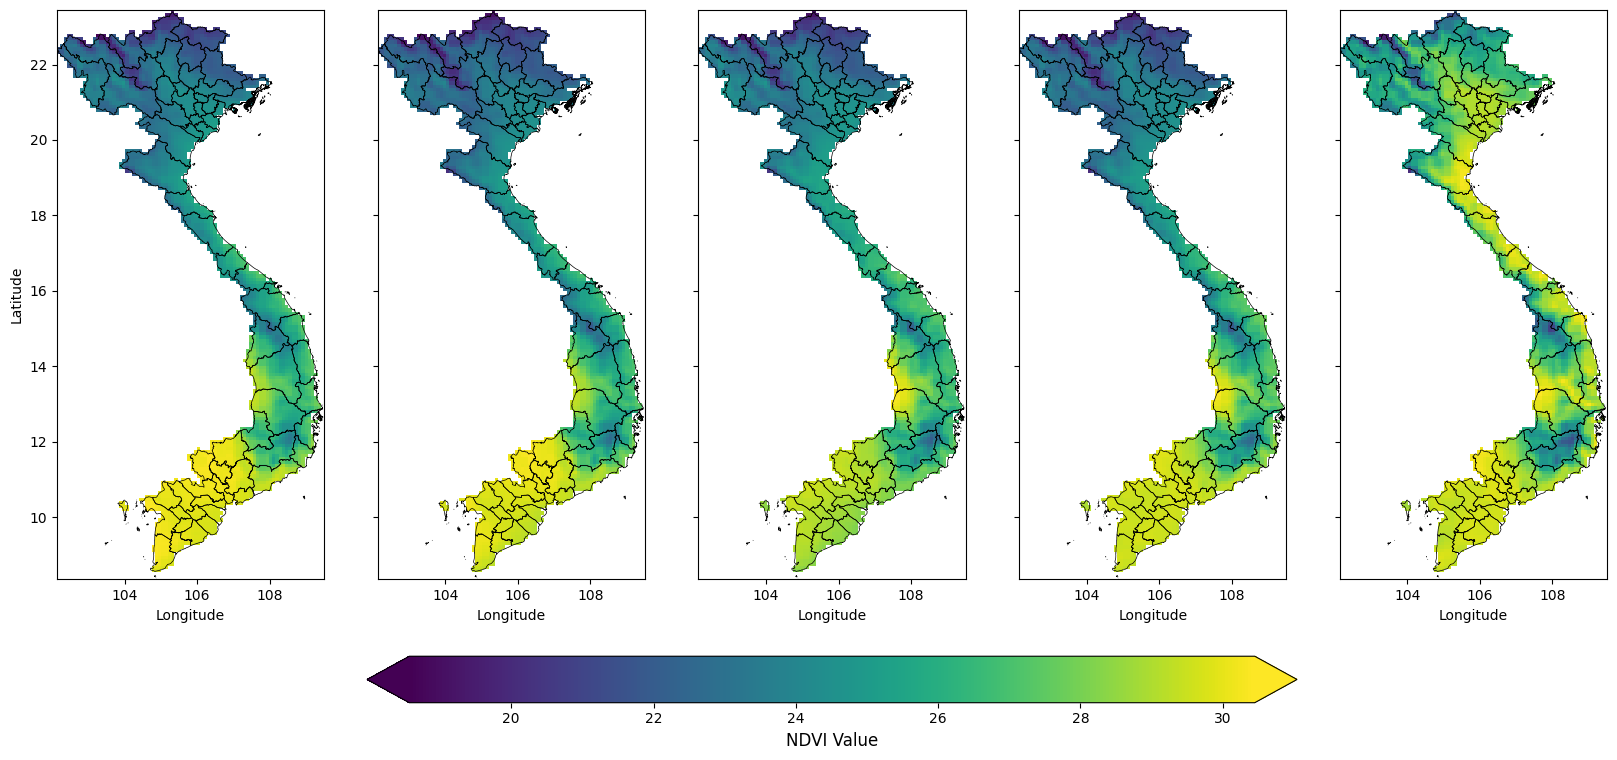

In [51]:
# Tạo figure và axes
fig, axes = plt.subplots(1, 5, figsize=(20, 10), sharex =True, sharey=True)
# Lấy 4 băng đầu tiên và hiển thị chúng
for i in range(5):
    band = temp[i]
    plot = band.plot(ax=axes[i], cmap='viridis', add_colorbar=False)  # Hiển thị băng mà không thêm colorbar
    axes[i].set_title('')
    axes[i].set_xlabel('Longitude', fontsize=10)
    axes[i].set_ylabel('Latitude', fontsize=10)
    axes[i].tick_params(axis='both', which='major', labelsize=8)
    # Vẽ đường viền của các tỉnh lên trên raster
    gdf.boundary.plot(ax=axes[i], edgecolor='black', linewidth=0.5)
    if i>0:
        axes[i].set_ylabel('') # Ẩn nhãn trục y cho các subplot bên phải
    axes[i].tick_params(axis='both', which='major', labelsize=10) # Tùy chỉnh kích thước chữ trục x
    # Các bạn có thể thêm điều chỉnh khác như lưới, nhãn trục, v.v. tùy ý
# Tạo colorbar chung cho tất cả các subplot
cbar = fig.colorbar(plot, 
                    ax=axes, orientation='horizontal', # Đặt colorbar nằm ngang dưới các subplot
                    pad=0.1, extend='both', shrink=0.6) # shrink để điều chỉnh kích thước colorbar

cbar.set_label('NDVI Value', fontsize=12) # Thêm nhãn cho colorbar
plt.show()

## Tóm tắt

Bạn đã hoàn thành Bài 20 và học được cách trực quan hóa dữ liệu địa không gian - kỹ năng quan trọng giúp hiểu sâu và truyền đạt thông tin từ dữ liệu bản đồ, ảnh vệ tinh, và các lớp địa lý khác.

### Các khái niệm chính đã nắm vững:
- ✅ **Hiển thị dữ liệu vector**: Vẽ dữ liệu điểm, đường, đa giác bằng GeoPandas và Matplotlib với tùy chỉnh màu sắc, lưới và nhãn trục
- ✅ **Hiển thị dữ liệu raster**: Đọc và hiển thị ảnh raster bằng RioXarray và Matplotlib với colormap linh hoạt
- ✅ **Kết hợp vector và raster**: Chồng dữ liệu vector lên raster để trực quan hóa đồng thời nhiều lớp địa lý trên cùng một biểu đồ
- ✅ **Nhiều subplot so sánh**: Tạo lưới subplot để so sánh nhiều băng dữ liệu raster cùng lúc với colorbar chung
- ✅ **Tùy chỉnh trục và lưới**: Định dạng kinh độ/vĩ độ với ký hiệu độ, điều chỉnh khoảng cách nhãn và kích thước chữ

### Kỹ năng bạn có thể áp dụng:
- Tạo bản đồ chuyên nghiệp từ dữ liệu vector địa lý với GeoPandas và Matplotlib
- Hiển thị và phân tích ảnh vệ tinh, dữ liệu raster nhiều băng một cách trực quan
- Kết hợp nhiều lớp dữ liệu địa không gian (vector + raster) trên cùng một biểu đồ
- Xây dựng bố cục subplot để so sánh chuỗi thời gian raster hoặc nhiều kịch bản dữ liệu
- Tích hợp kỹ năng trực quan hóa vào quy trình phân tích địa không gian hoàn chỉnh với Python